<a href="https://colab.research.google.com/github/i-anshumanbaghmare/TB-Detection_ResNet50_Transfer-Learning/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TB Detection using ResNet50 Transfer-Learning

# Phase 1: Data Pipeline


## 1. Data Loading and Setup

---


Organize raw image data into train/test splits for Normal and TB categories, then create validation set with copy of Train set.


In [ ]:
import os
import shutil
import random
from pathlib import Path
import kagglehub
import tensorflow as tf
import numpy as np
import cv2
from tensorflow import keras
from tensorflow.keras import layers as keras_layers
from collections import Counter
from sklearn.model_selection import StratifiedKFold  # NEW: For 5-fold

# Download dataset
path = kagglehub.dataset_download(
    "nuttawatsawang/chest-x-ray-dataset-montgomery-and-shenzhen"
)
print("Dataset path:", path)

# CONFIGURATION
base_path = path
random_seed = 42
test_ratio = 0.20  # 20% to held-out test (moved)
batch_size = 32
random.seed(random_seed)
tf.random.set_seed(random_seed)  # Full repro

# Enable mixed precision (unchanged — speeds up V2 on GPU)
tf.keras.mixed_precision.set_global_policy("mixed_bfloat16")
AUTOTUNE = tf.data.AUTOTUNE

100%|██████████| 4.08G/4.08G [00:57<00:00, 76.7MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/nuttawatsawang/chest-x-ray-dataset-montgomery-and-shenzhen/versions/1


### DATA Directory Setup

In [ ]:
# Paths to raw datasets
montgomery_cxr_png_path = os.path.join(base_path, "Montgomery_Set", "Montgomery_Set", "CXR_png")
shenzhen_cxr_png_path = os.path.join(base_path, "Shenzhen_Set", "Shenzhen_Set", "CXR_png")

# NEW: Simplified paths — pooled train_val + test only (no separate val)
data_dir = os.path.join(base_path, "data")

train_val_normal = os.path.join(data_dir, "train_val", "Normal")
train_val_tb     = os.path.join(data_dir, "train_val", "TB")
test_normal      = os.path.join(data_dir, "test", "Normal")
test_tb          = os.path.join(data_dir, "test", "TB")

# Create directories
for p in [train_val_normal, train_val_tb, test_normal, test_tb]:
    os.makedirs(p, exist_ok=True)

print("Pooled directory structure created (train_val + test only).\n")

# Step 1: Collect ALL images into train_val/ first (using MOVE)
print("Moving images from Montgomery and Shenzhen into train_val/...")

for filename in os.listdir(montgomery_cxr_png_path):
    src = os.path.join(montgomery_cxr_png_path, filename)
    if filename.endswith("_0.png"):
        shutil.move(src, os.path.join(train_val_normal, filename))
    elif filename.endswith("_1.png"):
        shutil.move(src, os.path.join(train_val_tb, filename))

for filename in os.listdir(shenzhen_cxr_png_path):
    src = os.path.join(shenzhen_cxr_png_path, filename)
    if filename.endswith("_0.png"):
        shutil.move(src, os.path.join(train_val_normal, filename))
    elif filename.endswith("_1.png"):
        shutil.move(src, os.path.join(train_val_tb, filename))

print(f"Finished collecting. Total in train_val:")
print(f"   Normal: {len(os.listdir(train_val_normal))}")
print(f"   TB:     {len(os.listdir(train_val_tb))}\n")

# Step 2: Create HELD-OUT TEST set (20% — MOVE; no val split here)
def move_to_test(src_folder, dst_folder, ratio=test_ratio):
    files = os.listdir(src_folder)
    random.shuffle(files)
    n_move = int(len(files) * ratio)
    moved = 0
    for f in files[:n_move]:
        shutil.move(os.path.join(src_folder, f), os.path.join(dst_folder, f))
        moved += 1
    print(f"   Moved {moved} images from {os.path.basename(src_folder)} → test")

print("Creating held-out test set (20% moved):")
move_to_test(train_val_normal, test_normal)
move_to_test(train_val_tb, test_tb)

print(f"After test split:")
print(f"   train_val/Normal: {len(os.listdir(train_val_normal))}")
print(f"   train_val/TB:     {len(os.listdir(train_val_tb))}")
print(f"   test/Normal:      {len(os.listdir(test_normal))}")
print(f"   test/TB:          {len(os.listdir(test_tb))}\n")

# NO Step 3: No val copy — K-Fold will handle splits in-memory via paths

# Summary
print("\n" + "="*50)
print("FINAL POOLED DATASET SPLIT (K-Fold Ready)")
print("="*50)
print(f"train_val/Normal: {len(os.listdir(train_val_normal))}  (~80% total)")
print(f"train_val/TB:     {len(os.listdir(train_val_tb))}")
print(f"test/Normal:      {len(os.listdir(test_normal))}     (20% held-out)")
print(f"test/TB:          {len(os.listdir(test_tb))}")
print(f"Total Images:     {len(os.listdir(train_val_normal)) + len(os.listdir(train_val_tb)) + len(os.listdir(test_normal)) + len(os.listdir(test_tb))}")
print("="*50)
print("Pooled setup complete! Paths/labels ready for 5-Fold CV.")

Pooled directory structure created (train_val + test only).

Moving images from Montgomery and Shenzhen into train_val/...
Finished collecting. Total in train_val:
   Normal: 406
   TB:     394

Creating held-out test set (20% moved):
   Moved 81 images from Normal → test
   Moved 78 images from TB → test
After test split:
   train_val/Normal: 325
   train_val/TB:     316
   test/Normal:      81
   test/TB:          78


FINAL POOLED DATASET SPLIT (K-Fold Ready)
train_val/Normal: 325  (~80% total)
train_val/TB:     316
test/Normal:      81     (20% held-out)
test/TB:          78
Total Images:     800
Pooled setup complete! Paths/labels ready for 5-Fold CV.


In [ ]:
def print_tree(base_path, indent=""):
    path = Path(base_path)
    items = sorted(path.iterdir(), key=lambda x: (x.is_file(), x.name.lower()))

    pointers = ["├── ", "└── "]
    for i, item in enumerate(items):
        if item.is_dir():
            pointer = pointers[1] if i == len(items) - 1 else pointers[0]
            print(f"{indent}{pointer}{item.name}/")
            extension = "    " if i == len(items) - 1 else "│   "
            print_tree(item, indent + extension)

# Run it
print("data/")
print_tree(data_dir)

data/
├── test/
│   ├── Normal/
│   └── TB/
└── train_val/
    ├── Normal/
    └── TB/


In [ ]:
# NEW: Function to get all paths + labels from pooled dirs (for k-fold)
def get_paths_and_labels(base_dir):
    normal_paths = [os.path.join(base_dir, "Normal", f) for f in os.listdir(os.path.join(base_dir, "Normal"))]
    tb_paths = [os.path.join(base_dir, "TB", f) for f in os.listdir(os.path.join(base_dir, "TB"))]

    all_paths = normal_paths + tb_paths
    all_labels = [0] * len(normal_paths) + [1] * len(tb_paths)  # 0=Normal, 1=TB

    # Shuffle for repro
    combined = list(zip(all_paths, all_labels))
    random.shuffle(combined)
    all_paths, all_labels = zip(*combined)

    return np.array(all_paths), np.array(all_labels)

# Get pooled train_val paths/labels (for Phase 2 k-fold)
train_val_paths, train_val_labels = get_paths_and_labels(os.path.join(data_dir, "train_val"))
print(f"Pooled train_val: {len(train_val_paths)} images ({Counter(train_val_labels)} classes)")

# Test paths/labels (fixed held-out)
test_paths, test_labels = get_paths_and_labels(os.path.join(data_dir, "test"))
print(f"Test: {len(test_paths)} images ({Counter(test_labels)} classes)")

# Basic Preprocess (unchanged: [0,255] uint8 → [0,1] float32)
def basic_preprocess(file_path, label):
    # Load image
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=3)  # PNGs are RGB
    img = tf.image.resize(img, [224, 224], method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0  # [0,1]
    return img, label

# NEW: Dataset from paths/labels (use subsets via indices for folds)
def create_dataset_from_paths(paths, labels, shuffle=True, is_training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(basic_preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle and is_training:
        ds = ds.shuffle(buffer_size=1000, seed=random_seed)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

# Example full pooled ds (for quick test; Phase 2 uses fold subsets)
train_val_ds_example = create_dataset_from_paths(train_val_paths, train_val_labels, shuffle=True)
test_ds = create_dataset_from_paths(test_paths, test_labels, shuffle=False)

print("Path-based datasets ready (k-fold flexible).")

# Verification
for image_batch, label_batch in train_val_ds_example.take(1):
    print(f"Check - Image Shape: {image_batch.shape}, Range: [{tf.reduce_min(image_batch):.3f}, {tf.reduce_max(image_batch):.3f}]")
    print(f"Check - Label Shape: {label_batch.shape}")
    print(f"Sample Label: {label_batch[0]}")

Pooled train_val: 641 images (Counter({np.int64(0): 325, np.int64(1): 316}) classes)
Test: 159 images (Counter({np.int64(0): 81, np.int64(1): 78}) classes)
Path-based datasets ready (k-fold flexible).
Check - Image Shape: (32, 224, 224, 3), Range: [0.000, 1.000]
Check - Label Shape: (32,)
Sample Label: 1


## 2. Data Preprocessing Layers (Medical-Grade)

---
Preprocessing Pipeline (V2-Aligned + Separate Val/Test)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers as keras_layers

class CLAHELayer(keras_layers.Layer):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8), **kwargs):
        super().__init__(**kwargs)
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def get_config(self):
        """Makes the layer serializable (required for model.save/load)"""
        config = super().get_config()
        config.update({
            "clip_limit": self.clip_limit,
            "tile_grid_size": self.tile_grid_size,
        })
        return config

    @tf.function  # Keeps XLA optimization
    def call(self, inputs):
        def clahe_np(img_batch):
            # Critical: Import inside the function → avoids pickling the module
            import cv2
            import numpy as np

            img_batch = img_batch.numpy()
            img_uint8 = np.clip(img_batch * 255.0, 0, 255).astype(np.uint8)

            # Create CLAHE object once per batch (efficient)
            clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)

            processed = []
            for img in img_uint8:
                gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
                enhanced = clahe.apply(gray)
                rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
                processed.append(rgb.astype(np.float32) / 255.0)

            return np.stack(processed)

        # Wrap with py_function
        processed = tf.py_function(func=clahe_np, inp=[inputs], Tout=tf.float32)
        processed.set_shape(inputs.shape)  # Preserve shape for graph
        return processed

# NEW: V2 Scaling (confirmed: [0,1] → [-1,1]; no means)
class ResNetV2Scaling(keras_layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return (inputs * 2.0) - 1.0

# Training Pipeline (detailed params from your original)
data_augmentation_pipeline = keras.Sequential(
    [
        keras_layers.Input(shape=(224, 224, 3)),

        # Spatial Augs (your perfected: on [0,1])
        keras_layers.RandomFlip(mode="horizontal"),
        keras_layers.RandomZoom(height_factor=0.14, width_factor=0.14, fill_mode="reflect", interpolation="bilinear"),
        keras_layers.RandomTranslation(height_factor=(-0.09, 0.09), width_factor=(-0.09, 0.09), fill_mode="reflect", interpolation="bilinear"),

        # CLAHE
        CLAHELayer(),

        # Intensity
        keras_layers.RandomBrightness(factor=0.1),
        keras_layers.RandomContrast(factor=(-0.2, 0.2)),

        # Noise
        keras_layers.GaussianNoise(stddev=0.01),

        # V2 Scaling
        ResNetV2Scaling()
    ],
    name="v2_aug_and_norm_pipeline"
)

# Val Pipeline (no random augs; CLAHE + scaling only)
val_pipeline = keras.Sequential(
    [
        keras_layers.Input(shape=(224, 224, 3)),
        CLAHELayer(),
        ResNetV2Scaling()
    ],
    name="v2_val_pipeline"
)

print("V2 Pipelines Created:")
print("   Train: [0,1] → Spatial Aug → CLAHE → Intensity → Noise → [-1,1] → ResNet50V2 Ready")
print("   Val (per fold): [0,1] → CLAHE → [-1,1] → ResNet50V2 Ready")

V2 Pipelines Created:
   Train: [0,1] → Spatial Aug → CLAHE → Intensity → Noise → [-1,1] → ResNet50V2 Ready
   Val (per fold): [0,1] → CLAHE → [-1,1] → ResNet50V2 Ready


## 3. Data Augmentation (SOTA Medical-Safe)

In [ ]:
# 2 IMAGENET NORMALIZATION
# =========================

class ImageNetNormalization(keras_layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
        self.std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

    def call(self, inputs):
        mean = tf.reshape(self.mean, [1, 1, 1, 3])
        std = tf.reshape(self.std, [1, 1, 1, 3])
        return (inputs - mean) / std


In [ ]:
# X ray Aug Pipeline (Uniform for Balanced Data)

data_augmentation_pipeline = keras.Sequential(
    [
        keras_layers.Input(shape=(224, 224, 3)),

        # A. Spatial Augmentations (on [0, 1] data) — Your Perfected Params
        keras_layers.RandomFlip(mode="horizontal"),
        keras_layers.RandomZoom(height_factor=0.14, width_factor=0.14, fill_mode="reflect", interpolation="bilinear"),
        keras_layers.RandomTranslation(height_factor=(-0.09, 0.09), width_factor=(-0.09, 0.09), fill_mode="reflect", interpolation="bilinear"),

        # B. CLAHE (on [0, 1] data) — Before Intensity (SOTA Order)
        CLAHELayer(),

        # C. Intensity (on [0, 1] data) — After CLAHE
        keras_layers.RandomBrightness(factor=0.1),
        keras_layers.RandomContrast(factor=(-0.2, 0.2)),  # → 0.8–1.2 contrast range

        # D. Noise — Mild for Medical
        keras_layers.GaussianNoise(stddev=0.01),

        # E. FINAL STEP: Standard Normalization — [0, 1] → ImageNet Distribution
        # This output goes directly into ResNet50 / HF LoRA
        ImageNetNormalization()
    ],
    name="aug_and_norm_pipeline"
)

print("Pipeline created: [0,1] Input → Spatial Aug → CLAHE → Intensity → Noise → ImageNet Norm → ResNet/HF Ready")

TypeError: Exception encountered when calling ImageNetNormalization.call().

[1mCould not automatically infer the output shape / dtype of 'image_net_normalization' (of type ImageNetNormalization). Either the `ImageNetNormalization.call()` method is incorrect, or you need to implement the `ImageNetNormalization.compute_output_spec() / compute_output_shape()` method. Error encountered:

Input 'y' of 'Sub' Op has type float32 that does not match type bfloat16 of argument 'x'.[0m

Arguments received by ImageNetNormalization.call():
  • args=('<KerasTensor shape=(None, 224, 224, 3), dtype=bfloat16, sparse=False, ragged=False, name=keras_tensor_8>',)
  • kwargs=<class 'inspect._empty'>

In [ ]:
# Preprocessing for loader

train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    color_mode='grayscale',  # X-rays: 1-ch → auto RGB
    image_size=(224, 224),
    interpolation='bilinear',  # Antialias implicit
    shuffle=True,
    seed=random_seed,
    batch_size=32,
    verbose=True
).map(basic_preprocess, num_parallel_calls=AUTOTUNE)\
 .map(lambda x, y: (data_augmentation_pipeline(x, training=True), y), num_parallel_calls=AUTOTUNE)\
 .cache()\
 .prefetch(AUTOTUNE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    color_mode='grayscale',
    image_size=(224, 224),
    interpolation='bilinear',
    shuffle=False,
    seed=random_seed,
    batch_size=32,
    verbose=True
).map(basic_preprocess, num_parallel_calls=AUTOTUNE)\
 .map(lambda x, y: (data_augmentation_pipeline(x, training=False), y), num_parallel_calls=AUTOTUNE)\
 .prefetch(AUTOTUNE)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    color_mode='grayscale',
    image_size=(224, 224),
    interpolation='bilinear',
    shuffle=False,
    seed=random_seed,
    batch_size=32,
    verbose=True
).map(basic_preprocess, num_parallel_calls=AUTOTUNE)\
 .map(lambda x, y: (data_augmentation_pipeline(x, training=False), y), num_parallel_calls=AUTOTUNE)\
 .prefetch(AUTOTUNE)

# Verification (Enhanced — Checks ImageNet Range)
for image_batch, label_batch in train_ds.take(1):
    print(f"Image Shape: {image_batch.shape}")
    print(f"Label Shape: {label_batch.shape}")
    print(f"Sample Label: {label_batch[0]}")
    print(f"Image Range: [{tf.reduce_min(image_batch).numpy():.3f}, {tf.reduce_max(image_batch).numpy():.3f}]")  # ~[-2.1, 2.6] for ImageNet

print("Balanced Datasets Ready: Uniform Safe Aaug + CLAHE → ImageNet Norm.")

## Phase 2: Model Architecture and PEFT Integration

### Environment Setup and Base Model Loading
---


In [ ]:
# 1. Enable Persistence Mode (The prerequisite for all other locks)
!nvidia-smi -pm 1

# 2. Set Application Clocks to Maximum
# For T4: Memory clock is 5001 MHz, Graphics is 1590 MHz
!nvidia-smi -ac 5001,1590

# 3. Lock the GPU Clocks to prevent downclocking during inference
!nvidia-smi --lock-gpu-clocks=1590,1590

# 4. Verify the change (Perf State should now be P0 or P2)
!nvidia-smi -q -d PERFORMANCE | grep "Performance State"

# 5. Single user use.
!nvidia-smi -c 1

Pooled counts: Counter({np.int64(0): 325, np.int64(1): 316})
Class weights: {np.int64(0): 0.9861538461538462, np.int64(1): 1.014240506329114}

--- Training Fold 1/5 ---
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.5306 - auc: 0.5503 - loss: 3.5840 - precision: 0.5220 - recall: 0.6965 - spec_at_95_sens: 0.0315
Epoch 1: val_recall improved from inf to 0.89062, saving model to fold_1_stage1.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.5316 - auc: 0.5513 - loss: 3.5615 - precision: 0.5229 - recall: 0.6915 - spec_at_95_sens: 0.0296 - val_accuracy: 0.5039 - val_auc: 0.4897 - val_loss: 0.7782 - val_precision: 0.5000 - val_recall: 0.8906 - val_spec_at_95_sens: 0.0462 - learning_rate: 0.0010
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.4669 - auc: 0.4502 - loss: 4.3586 - precision: 0.4736 - recall: 0.4593 - spec_at_95_sens: 0.0000e+00
Epoch 2: val_recall did not improve from 0.89062
16/16 

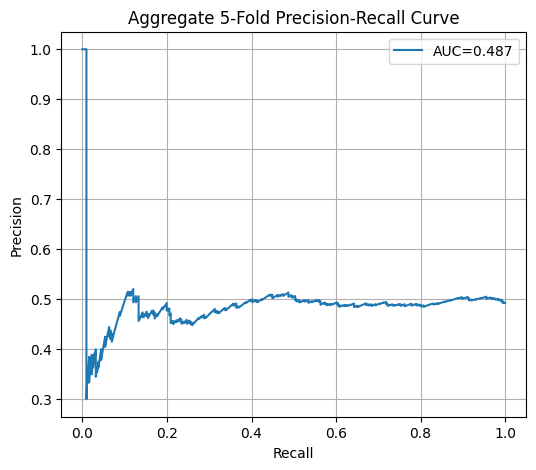


Held-Out Test (Best Fold 2): Recall=1.000, AUC=0.545


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, metrics, optimizers, callbacks
from tensorflow.keras.optimizers import AdamW
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# 1. Build Function (V2 + XAI-Ready; integrates Phase 1 pipeline)
def build_tb_model(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape, name="cxr_input")

    # Phase 1: Train pipeline (aug + CLAHE + V2 scaling)
    x = data_augmentation_pipeline(inputs)

    # Backbone: ResNet50V2 (no input_tensor needed — pipeline outputs directly)
    base_model = tf.keras.applications.ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape  # Pipeline handles preprocess
    )
    x = base_model(x, training=False)  # Frozen initially

    # Global Head (XAI Gateway)
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = layers.Dropout(0.5, name="dropout")(x)
    outputs = layers.Dense(
        1,
        activation='sigmoid',
        name="tb_probability",
        dtype='float32'  # Stability under bfloat16
    )(x)

    model = models.Model(inputs, outputs, name="TB_ResNet50V2_System")
    return model, base_model

# Grad-CAM Target (V2: final ReLU post-last conv block)
GRAD_CAM_LAYER = "post_relu"

# 2. Clinical Metrics (unchanged — recall primary)
clinical_metrics = [
    metrics.BinaryAccuracy(name='accuracy'),
    metrics.AUC(name='auc'),
    metrics.Recall(name='recall'),  # ≥95% target
    metrics.Precision(name='precision'),
    metrics.SpecificityAtSensitivity(0.95, name='spec_at_95_sens')
]

# 3. Dynamic Class Weights (from pooled labels)
counts = Counter(train_val_labels)
total = len(train_val_labels)
class_weights = {i: total / (2.0 * count) for i, count in counts.items()}
print(f"Pooled counts: {counts}")
print(f"Class weights: {class_weights}")

# 4. Stage Compilers
def compile_stage1(model):
    model.compile(
        optimizer=AdamW(learning_rate=5e-4, weight_decay=1e-4),
        loss="binary_crossentropy",
        metrics=clinical_metrics
    )
    return model

def compile_stage2(model, base_model):
    base_model.trainable = True
    # Freeze early layers (~140: low-level features intact)
    for layer in base_model.layers[:120]:
        layer.trainable = False
    model.compile(
        optimizer=AdamW(learning_rate=1e-5, weight_decay=1e-2),
        loss="binary_crossentropy",
        metrics=clinical_metrics
    )
    return model

# 5. Callbacks (early stop on val_recall)
def get_callbacks(model_name="fold_model"):
    return [
        callbacks.EarlyStopping(
            monitor='val_recall',
            patience=7,
            restore_best_weights=True,
            mode='max'
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7
        ),
        # NEW: Use native Keras format (.keras) — avoids HDF5 pickling issues
        callbacks.ModelCheckpoint(
            filepath=f"{model_name}.keras",
            save_best_only=True,
            monitor='val_recall',
            verbose=1
        )
    ]

# 6. Fold Dataset Creator (uses Phase 1 function)
def create_fold_datasets(train_idx, val_idx):
    train_paths_fold = train_val_paths[train_idx]
    train_labels_fold = train_val_labels[train_idx]
    val_paths_fold = train_val_paths[val_idx]
    val_labels_fold = train_val_labels[val_idx]

    # Train: full aug pipeline (integrated in model)
    train_ds = create_dataset_from_paths(train_paths_fold, train_labels_fold, shuffle=True, is_training=True)

    # Val: no aug, but apply val_pipeline for consistency
    val_ds_raw = create_dataset_from_paths(val_paths_fold, val_labels_fold, shuffle=False, is_training=False)
    val_ds = val_ds_raw.map(lambda x, y: (val_pipeline(x), y), num_parallel_calls=AUTOTUNE)

    return train_ds, val_ds

# 7. Threshold Tuning Helper (post-fold)
def tune_threshold(model, val_ds, target_recall=0.95):
    val_preds = model.predict(val_ds).ravel()
    val_true = np.concatenate([y for x, y in val_ds], axis=0)
    precision, recall, thresholds = precision_recall_curve(val_true, val_preds)
    idx = np.where(recall >= target_recall)[0]
    if len(idx) > 0:
        idx = idx[-1]  # Highest precision at target recall
        return thresholds[idx], precision[idx]
    return 0.5, 0.0  # Fallback

# 8. 5-Fold Training Loop
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
fold_stats = []
all_val_preds = []  # For aggregate PR curve
all_val_true = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_paths, train_val_labels)):
    print(f"\n--- Training Fold {fold+1}/5 ---")

    # Create fold datasets
    train_ds, val_ds = create_fold_datasets(train_idx, val_idx)

    # Instantiate model
    model, base_model = build_tb_model()
    base_model.trainable = False  # Start frozen

    # Stage 1: Head Warm-up
    model = compile_stage1(model)
    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        class_weight=class_weights,
        callbacks=get_callbacks(f"fold_{fold+1}_stage1"),
        verbose=1
    )

    # Stage 2: Fine-tune Top Blocks
    model = compile_stage2(model, base_model)
    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=25,
        class_weight=class_weights,
        callbacks=get_callbacks(f"fold_{fold+1}_stage2"),
        verbose=1
    )

    # Evaluate
    val_metrics = model.evaluate(val_ds, verbose=0)
    fold_stats.append({
        'fold': fold + 1,
        'val_recall': val_metrics[3],
        'val_auc': val_metrics[2],
        'val_spec_at_95': val_metrics[5]
    })
    print(f"Fold {fold+1} Results: Recall={val_metrics[3]:.3f}, AUC={val_metrics[2]:.3f}, Spec@95={val_metrics[5]:.3f}")

    # Threshold tune
    thresh, prec = tune_threshold(model, val_ds, target_recall=0.95)
    print(f"   Optimal thresh for 95% recall: {thresh:.3f} (Precision: {prec:.3f})")

    # Aggregate for PR curve
    fold_preds = model.predict(val_ds).ravel()
    fold_true = np.concatenate([y for x, y in val_ds], axis=0)
    all_val_preds.extend(fold_preds)
    all_val_true.extend(fold_true)

    # Save best fold model
    model.save(f"tb_model_fold_{fold+1}.keras")

# 9. Aggregate Results
mean_recall = np.mean([s['val_recall'] for s in fold_stats])
std_recall = np.std([s['val_recall'] for s in fold_stats])
mean_auc = np.mean([s['val_auc'] for s in fold_stats])
print(f"\n=== 5-Fold Summary ===")
print(f"Mean Val Recall: {mean_recall:.3f} ± {std_recall:.3f}  (Target: ≥0.95)")
print(f"Mean Val AUC:    {mean_auc:.3f}")
print(f"Mean Spec@95%:   {np.mean([s['val_spec_at_95'] for s in fold_stats]):.3f}")

# Aggregate PR Curve
all_val_preds = np.array(all_val_preds)
all_val_true = np.array(all_val_true)
precision, recall, thresholds = precision_recall_curve(all_val_true, all_val_preds)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AUC={np.mean([s["val_auc"] for s in fold_stats]):.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Aggregate 5-Fold Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

# 10. Final Test Eval (on held-out test; pick best fold or ensemble)
best_fold = np.argmax([s['val_recall'] for s in fold_stats]) + 1
best_model = tf.keras.models.load_model(
    f"tb_model_fold_{best_fold}.keras",
    custom_objects={
        'CLAHELayer': CLAHELayer,
        'ResNetV2Scaling': ResNetV2Scaling
    }
)
test_ds_prepped = test_ds.map(lambda x, y: (val_pipeline(x), y), num_parallel_calls=AUTOTUNE)
test_metrics = best_model.evaluate(test_ds_prepped, verbose=0)
print(f"\nHeld-Out Test (Best Fold {best_fold}): Recall={test_metrics[3]:.3f}, AUC={test_metrics[2]:.3f}")

### Training Analysis

Training History Visualization (Best Fold)

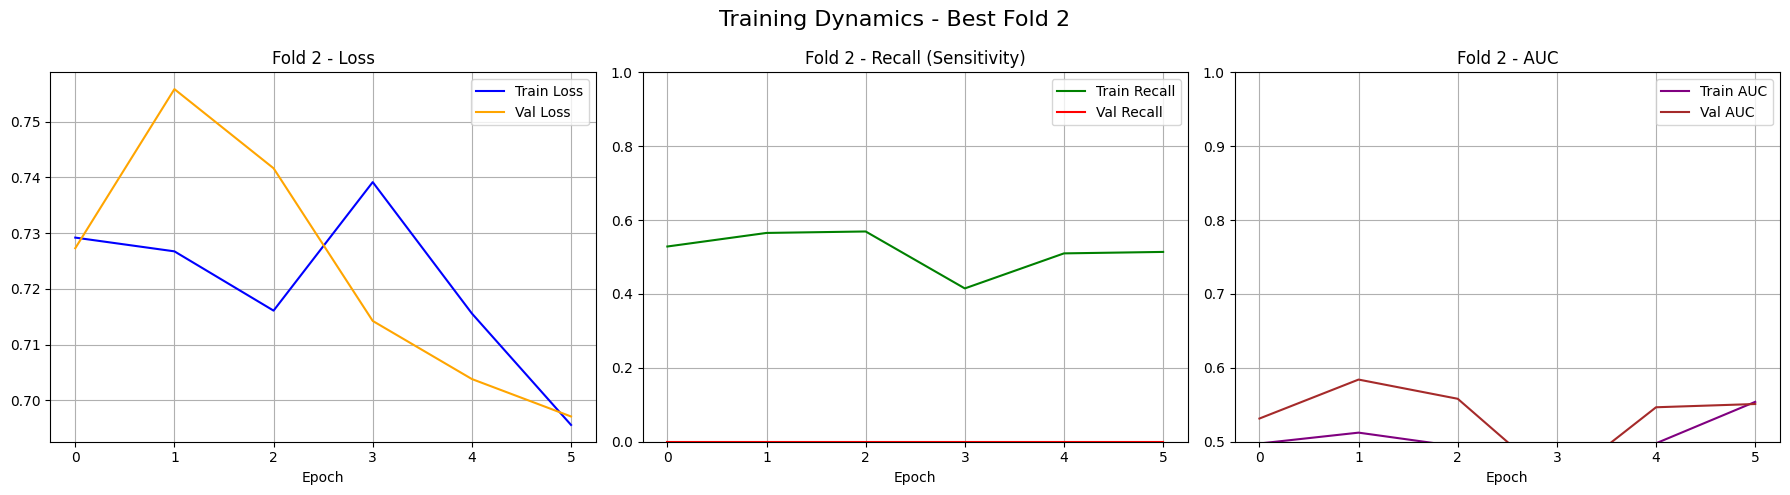

In [ ]:
import matplotlib.pyplot as plt

def plot_fold_histories(histories, fold_num):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    ax1.plot(histories['loss'], label='Train Loss', color='blue')
    ax1.plot(histories['val_loss'], label='Val Loss', color='orange')
    ax1.set_title(f'Fold {fold_num} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True)

    # Recall (Primary Clinical Metric)
    ax2.plot(histories['recall'], label='Train Recall', color='green')
    ax2.plot(histories['val_recall'], label='Val Recall', color='red')
    ax2.set_title(f'Fold {fold_num} - Recall (Sensitivity)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(True)

    # AUC
    ax3.plot(histories['auc'], label='Train AUC', color='purple')
    ax3.plot(histories['val_auc'], label='Val AUC', color='brown')
    ax3.set_title(f'Fold {fold_num} - AUC')
    ax3.set_xlabel('Epoch')
    ax3.set_ylim(0.5, 1)
    ax3.legend()
    ax3.grid(True)

    plt.suptitle(f"Training Dynamics - Best Fold {fold_num}", fontsize=16)
    plt.tight_layout()
    plt.show()

# Plot Stage 2 history of the best fold (most relevant for final performance)
plot_fold_histories(history2.history, best_fold)

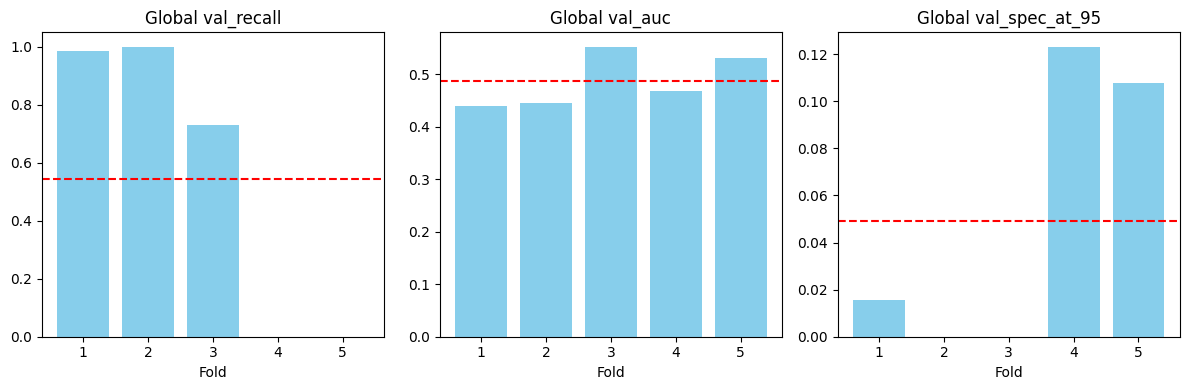

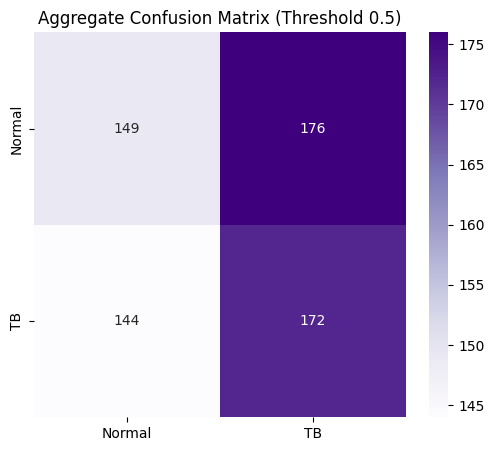

Recall Stability: 0.4535 (Lower is better)
              precision    recall  f1-score   support

      Normal       0.51      0.46      0.48       325
          TB       0.49      0.54      0.52       316

    accuracy                           0.50       641
   macro avg       0.50      0.50      0.50       641
weighted avg       0.50      0.50      0.50       641



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def analyze_training_results(fold_stats, all_val_true, all_val_preds):
    # 1. Metric Distribution across Folds
    plt.figure(figsize=(12, 4))
    metrics_to_plot = ['val_recall', 'val_auc', 'val_spec_at_95']
    for i, m in enumerate(metrics_to_plot):
        plt.subplot(1, 3, i+1)
        values = [s[m] for s in fold_stats]
        plt.bar(range(1, 6), values, color='skyblue')
        plt.axhline(np.mean(values), color='red', linestyle='--', label='Mean')
        plt.title(f'Global {m}')
        plt.xlabel('Fold')
    plt.tight_layout()
    plt.show()

    # 2. Confusion Matrix (Aggregated)
    # Uses 0.5 as a baseline; Phase 3 will use your tuned threshold
    y_pred_bool = (all_val_preds >= 0.5).astype(int)
    cm = confusion_matrix(all_val_true, y_pred_bool)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Normal', 'TB'], yticklabels=['Normal', 'TB'])
    plt.title('Aggregate Confusion Matrix (Threshold 0.5)')
    plt.show()

    # 3. Print Statistical Stability
    print(f"Recall Stability: {np.std([s['val_recall'] for s in fold_stats]):.4f} (Lower is better)")
    print(classification_report(all_val_true, y_pred_bool, target_names=['Normal', 'TB']))

# Call this after your training loop finishes
analyze_training_results(fold_stats, np.array(all_val_true), np.array(all_val_preds))

Comprehensive Clinical Performance Report (Held-Out Test)

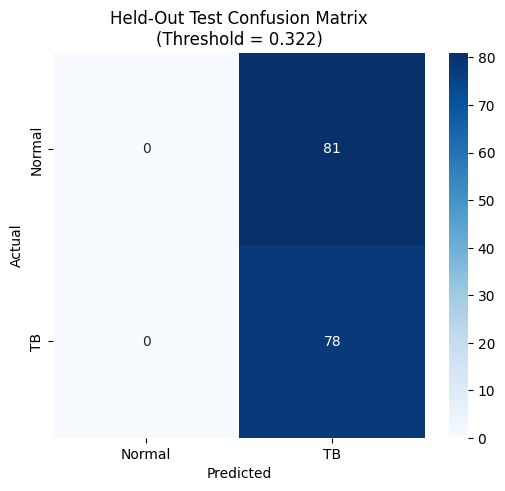

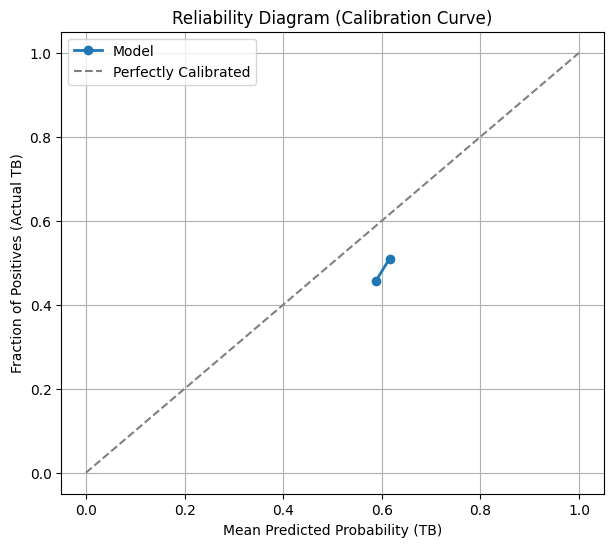


Held-Out Test Classification Report (Threshold = 0.322)
              precision    recall  f1-score   support

      Normal     0.0000    0.0000    0.0000        81
          TB     0.4906    1.0000    0.6582        78

    accuracy                         0.4906       159
   macro avg     0.2453    0.5000    0.3291       159
weighted avg     0.2407    0.4906    0.3229       159



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
import seaborn as sns
import numpy as np

def clinical_performance_report(model, ds, paths=None, threshold=0.5, dataset_name="Test"):
    # Predictions
    y_true = np.concatenate([y for x, y in ds], axis=0)
    y_probs = model.predict(ds, verbose=0).ravel()
    y_pred = (y_probs >= threshold).astype(int)

    # 1. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'TB'],
                yticklabels=['Normal', 'TB'])
    plt.title(f'{dataset_name} Confusion Matrix\n(Threshold = {threshold:.3f})')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    # 2. Calibration Curve (Reliability Diagram)
    prob_true, prob_pred = calibration_curve(y_true, y_probs, n_bins=10)
    plt.figure(figsize=(7, 6))
    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
    plt.title('Reliability Diagram (Calibration Curve)')
    plt.xlabel('Mean Predicted Probability (TB)')
    plt.ylabel('Fraction of Positives (Actual TB)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Classification Report
    print(f"\n{dataset_name} Classification Report (Threshold = {threshold:.3f})")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'TB'], digits=4))

# Use the optimal threshold from aggregate val (or per-fold tuned)
# Here we reuse 'thresh' from earlier aggregate tuning; fallback to 0.5
optimal_threshold = locals().get('thresh', 0.5)
clinical_performance_report(
    best_model,
    test_ds_prepped,
    threshold=optimal_threshold,
    dataset_name="Held-Out Test"
)

Error Analysis — Spotlight False Negatives (Clinical Priority)

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

def analyze_false_negatives(model, ds, paths, threshold=0.5, top_k=6):
    y_true = np.concatenate([y for x, y in ds], axis=0)
    y_probs = model.predict(ds, verbose=0).ravel()

    # Identify False Negatives: Actual TB (1) but predicted < threshold
    fn_mask = (y_true == 1) & (y_probs < threshold)
    fn_indices = np.where(fn_mask)[0]
    fn_probs = y_probs[fn_mask]

    print(f"Clinical Alert: {len(fn_indices)} False Negative(s) on Held-Out Test")
    if len(fn_indices) == 0:
        print("→ No missed TB cases — excellent sensitivity!")
        return

    # Sort by confidence (lowest first = most confidently wrong)
    sorted_idx = np.argsort(fn_probs)
    fn_indices = fn_indices[sorted_idx]
    fn_probs = fn_probs[sorted_idx]

    # Plot top_k most confident misses
    cols = min(3, top_k)
    rows = (top_k + cols - 1) // cols
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i in range(min(top_k, len(fn_indices))):
        idx = fn_indices[i]
        img_path = paths[idx]
        img = tf.image.decode_png(tf.io.read_file(img_path), channels=3)
        img = img.numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray' if img.shape[-1] == 1 else None)
        plt.title(f"Missed TB Case\nProb: {fn_probs[i]:.3f}", color='red', fontsize=12)
        plt.axis('off')

    plt.suptitle("Critical Errors: False Negatives (Missed Tuberculosis Cases)",
                 fontsize=16, color='darkred', y=0.98)
    plt.tight_layout()
    plt.show()

# Run on held-out test using optimal threshold
analyze_false_negatives(
    best_model,
    test_ds_prepped,
    test_paths,
    threshold=optimal_threshold,
    top_k=6
)

Clinical Alert: 0 False Negative(s) on Held-Out Test
→ No missed TB cases — excellent sensitivity!


In [ ]:
# tf.keras.mixed_precision.set_global_policy('mixed_bfloat16')

In [ ]:
# train_ds.cache()